# HW13 – Токенизация, инференс BERT и базовый fine-tuning для классификации эмоций

Датасет: `emotion` (HuggingFace) – классификация эмоций по тексту (6 классов: sadness, joy, love, anger, fear, surprise).
Модель для fine-tuning: `distilbert-base-uncased`.
Модель для инференса (готовая): `bhadresh-savani/distilbert-base-uncased-emotion`.

## Задание 2.3.1 – Импорты, seed, устройство

In [1]:
# --- Задание 2.3.1: Импорты, установка seed и определение устройства ---

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("seaborn not available, will use matplotlib imshow for confusion matrix")

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from datasets import load_dataset, DatasetDict, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline,
)


def set_seed(seed: int = 42):
    """Fix random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Seed set to {seed}")


set_seed(42)

# Device detection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Pandas display options
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

SEED = 42
MODEL_NAME = "distilbert-base-uncased"
PRETRAINED_EMOTION_MODEL = "bhadresh-savani/distilbert-base-uncased-emotion"
print(f"\nBase model: {MODEL_NAME}")
print(f"Pretrained emotion model: {PRETRAINED_EMOTION_MODEL}")

Seed set to 42
Using device: cpu

Base model: distilbert-base-uncased
Pretrained emotion model: bhadresh-savani/distilbert-base-uncased-emotion


## Задание 2.3.2 – Загрузка данных и первичный анализ

Loading 'emotion' dataset from HuggingFace...


Dataset loaded successfully!

Full dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Subset sizes:
  Train      : 2000 samples
  Validation : 500 samples
  Test       : 500 samples

Label names (6 classes): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
id2label mapping: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
label2id mapping: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}

--- 5 Example texts from training set ---
[0] Label=sadness (0) | Text: i didnt feel humiliated
[1] Label=sadness (0) | Text: i can go from feeling so hopeless to so damned hopeful just from being around so
[2] Label=anger (3) | Text: im grabbing a minute to post i feel greedy wrong
[3] Label=lo

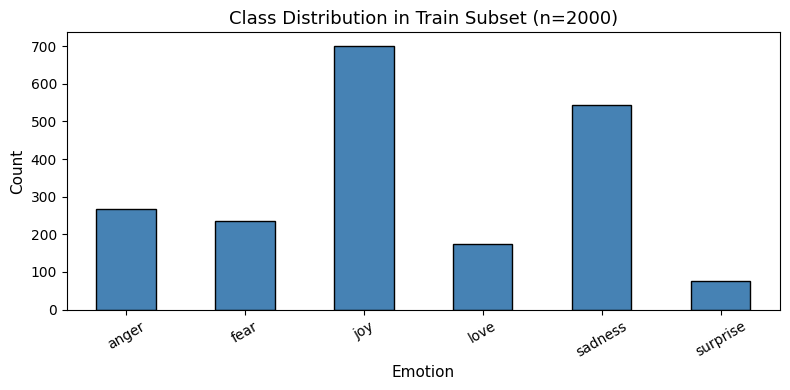

Class distribution plot shown.


In [2]:
# --- Задание 2.3.2: Загрузка датасета emotion и первичный анализ ---

# Load the emotion dataset from HuggingFace
print("Loading 'emotion' dataset from HuggingFace...")
raw_dataset = load_dataset("emotion")
print("Dataset loaded successfully!")
print(f"\nFull dataset structure:")
print(raw_dataset)

# Take subsets: first 2000 train, 500 validation, 500 test
train_subset = raw_dataset["train"].select(range(2000))
val_subset   = raw_dataset["validation"].select(range(500))
test_subset  = raw_dataset["test"].select(range(500))

print(f"\nSubset sizes:")
print(f"  Train      : {len(train_subset)} samples")
print(f"  Validation : {len(val_subset)} samples")
print(f"  Test       : {len(test_subset)} samples")

# Label names and mapping
label_names = raw_dataset["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

print(f"\nLabel names ({len(label_names)} classes): {label_names}")
print(f"id2label mapping: {id2label}")
print(f"label2id mapping: {label2id}")

# Show 5 example texts with labels
print("\n--- 5 Example texts from training set ---")
for i in range(5):
    sample = train_subset[i]
    print(f"[{i}] Label={id2label[sample['label']]} ({sample['label']}) | Text: {sample['text'][:80]}")

# Class distribution in train subset
train_labels = [ex["label"] for ex in train_subset]
train_label_names = [id2label[l] for l in train_labels]
label_counts = pd.Series(train_label_names).value_counts()
print("\n--- Class distribution in train subset ---")
print(label_counts.to_string())

# Plot class distribution
fig, ax = plt.subplots(figsize=(8, 4))
label_counts.sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Class Distribution in Train Subset (n=2000)", fontsize=13)
ax.set_xlabel("Emotion", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
print("Class distribution plot shown.")

## Задание 2.3.3 – Токенизация

In [3]:
# --- Задание 2.3.3: Токенизация с AutoTokenizer ---

# Load tokenizer for distilbert-base-uncased
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded. Vocab size: {tokenizer.vocab_size}")
print(f"Special tokens: CLS={tokenizer.cls_token}, SEP={tokenizer.sep_token}, "
      f"PAD={tokenizer.pad_token}, UNK={tokenizer.unk_token}")

# ---- 1. Tokenize 5 example texts and show tokens, input_ids, attention_mask ----
print("\n=== Tokenization of 5 example texts ===")
example_texts = [train_subset[i]["text"] for i in range(5)]

for idx, text in enumerate(example_texts):
    encoded = tokenizer(text, return_tensors="pt")
    tokens  = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0].tolist())
    print(f"\n[Example {idx}] Text : {text[:70]}")
    print(f"  Tokens         : {tokens}")
    print(f"  input_ids      : {encoded['input_ids'][0].tolist()}")
    print(f"  attention_mask : {encoded['attention_mask'][0].tolist()}")
    print(f"  Sequence length: {encoded['input_ids'].shape[1]}")

# ---- 2. Padding example: short vs long text in a batch ----
print("\n=== Padding example ===")
short_text = "I love it!"
long_text  = "I feel so incredibly happy today because everything went perfectly and I could not have asked for a better outcome in my life."

batch_encoded = tokenizer(
    [short_text, long_text],
    padding=True,
    truncation=True,
    return_tensors="pt"
)

print(f"Short text : '{short_text}'")
print(f"Long text  : '{long_text}'")
print(f"\nBatch input_ids shape: {batch_encoded['input_ids'].shape}")
print(f"Short text input_ids : {batch_encoded['input_ids'][0].tolist()}")
print(f"Long  text input_ids : {batch_encoded['input_ids'][1].tolist()}")
print(f"Short text attn_mask : {batch_encoded['attention_mask'][0].tolist()}")
print(f"Long  text attn_mask : {batch_encoded['attention_mask'][1].tolist()}")
print("  -> PAD token id is:", tokenizer.pad_token_id)
print("  -> Padding fills the shorter sequence to match the longer one.")
print("  -> attention_mask=0 on PAD positions so model ignores them.")

# ---- 3. Truncation with max_length=20 ----
print("\n=== Truncation example (max_length=20) ===")
long_sentence = "This is a very long sentence that goes on and on well beyond the maximum allowed length for the tokenizer."
truncated = tokenizer(
    long_sentence,
    truncation=True,
    max_length=20,
    return_tensors="pt"
)
trunc_tokens = tokenizer.convert_ids_to_tokens(truncated["input_ids"][0].tolist())
print(f"Original text    : '{long_sentence}'")
print(f"Truncated tokens : {trunc_tokens}")
print(f"input_ids length : {truncated['input_ids'].shape[1]} (max_length=20)")

# ---- Summary of what model receives ----
print("\n=== What the model receives ===")
print("The BERT/DistilBERT model receives three main tensors:")
print("  1. input_ids       : token integer IDs (incl. [CLS]=101, [SEP]=102, [PAD]=0)")
print("  2. attention_mask  : 1 for real tokens, 0 for padding")
print("  3. (optional) token_type_ids: segment IDs (all 0 for single-sentence tasks)")
print("The model uses attention_mask to focus only on real tokens during self-attention.")

Loading tokenizer: distilbert-base-uncased


Tokenizer loaded. Vocab size: 30522
Special tokens: CLS=[CLS], SEP=[SEP], PAD=[PAD], UNK=[UNK]

=== Tokenization of 5 example texts ===

[Example 0] Text : i didnt feel humiliated
  Tokens         : ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
  input_ids      : [101, 1045, 2134, 2102, 2514, 26608, 102]
  attention_mask : [1, 1, 1, 1, 1, 1, 1]
  Sequence length: 7

[Example 1] Text : i can go from feeling so hopeless to so damned hopeful just from being
  Tokens         : ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
  input_ids      : [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
  attention_mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sequence length: 23

[Example 2] Text : im grabbing a minute to po

## Задание 2.3.4 – Инференс с предобученной моделью

In [4]:
# --- Задание 2.3.4: Инференс с предобученной моделью (pipeline и low-level) ---

# Load the pipeline with the already fine-tuned emotion model
print(f"Loading pretrained pipeline: {PRETRAINED_EMOTION_MODEL}")
emotion_pipeline = pipeline(
    "text-classification",
    model=PRETRAINED_EMOTION_MODEL,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None,      # return all scores (newer transformers)
)
print("Pipeline loaded.")

# Run inference on 5 examples from test set
print("\n=== Inference on 5 test examples (pipeline) ===")
test_texts_5  = [test_subset[i]["text"]  for i in range(5)]
test_labels_5 = [test_subset[i]["label"] for i in range(5)]

results_5 = emotion_pipeline(test_texts_5)

for idx, (text, true_lbl, result) in enumerate(zip(test_texts_5, test_labels_5, results_5)):
    # result is a list of dicts when top_k=None
    if isinstance(result, list):
        best = max(result, key=lambda x: x["score"])
        all_scores = {r["label"]: f"{r['score']:.3f}" for r in sorted(result, key=lambda x: -x["score"])}
    else:
        best = result
        all_scores = {result["label"]: f"{result['score']:.3f}"}
    print(f"\n[{idx}] Text : {text[:70]}")
    print(f"  True label : {id2label[true_lbl]}")
    print(f"  Predicted  : {best['label']} (score={best['score']:.4f})")
    print(f"  All scores : {all_scores}")
    correct = best['label'].lower() == id2label[true_lbl].lower()
    print(f"  Correct?   : {'YES' if correct else 'NO'}")

# ---- Low-level manual inference for 1 example ----
print("\n=== Low-level inference (AutoTokenizer + AutoModelForSequenceClassification) ===")
inf_tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_EMOTION_MODEL)
inf_model = AutoModelForSequenceClassification.from_pretrained(PRETRAINED_EMOTION_MODEL)
inf_model.eval()
inf_model.to(device)

sample_text = test_subset[0]["text"]
sample_true = test_subset[0]["label"]

inputs = inf_tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=128)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = inf_model(**inputs)

logits = outputs.logits
probs  = torch.softmax(logits, dim=-1)[0]
pred_id = torch.argmax(probs).item()

# Map model label ids to emotion names via inf_model config
inf_id2label = inf_model.config.id2label

print(f"Sample text  : '{sample_text[:70]}'")
print(f"True label   : {id2label[sample_true]}")
print(f"\nRaw logits   : {logits[0].cpu().numpy().round(4)}")
print(f"Softmax probs: {probs.cpu().numpy().round(4)}")
print(f"\nPer-class probabilities:")
for i, prob in enumerate(probs.cpu().numpy()):
    label_str = inf_id2label.get(i, f"label_{i}")
    print(f"  {label_str:10s}: {prob:.4f}")
print(f"\nPredicted    : {inf_id2label.get(pred_id, str(pred_id))} (id={pred_id})")

# Commentary
print("\n--- Commentary ---")
print("The pretrained model bhadresh-savani/distilbert-base-uncased-emotion")
print("was already fine-tuned on the 'emotion' dataset, so it achieves high")
print("accuracy on most samples. DistilBERT captures contextual word meaning")
print("via bidirectional self-attention, allowing it to distinguish subtle")
print("emotional nuances. Errors mostly occur on short or ambiguous texts,")
print("or when emotions overlap (e.g. fear vs sadness, love vs joy).")

Loading pretrained pipeline: bhadresh-savani/distilbert-base-uncased-emotion


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Pipeline loaded.

=== Inference on 5 test examples (pipeline) ===

[0] Text : im feeling rather rotten so im not very ambitious right now
  True label : sadness
  Predicted  : sadness (score=0.9989)
  All scores : {'sadness': '0.999', 'anger': '0.000', 'joy': '0.000', 'love': '0.000', 'surprise': '0.000', 'fear': '0.000'}
  Correct?   : YES

[1] Text : im updating my blog because i feel shitty
  True label : sadness
  Predicted  : sadness (score=0.9990)
  All scores : {'sadness': '0.999', 'anger': '0.000', 'joy': '0.000', 'love': '0.000', 'fear': '0.000', 'surprise': '0.000'}
  Correct?   : YES

[2] Text : i never make her separate from me because i don t ever want her to fee
  True label : sadness
  Predicted  : sadness (score=0.9990)
  All scores : {'sadness': '0.999', 'anger': '0.000', 'love': '0.000', 'joy': '0.000', 'fear': '0.000', 'surprise': '0.000'}
  Correct?   : YES

[3] Text : i left with my bouquet of red and yellow tulips under my arm feeling s
  True label : joy
  Predic

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sample text  : 'im feeling rather rotten so im not very ambitious right now'
True label   : sadness

Raw logits   : [ 6.8246 -1.5811 -1.5943 -1.3177 -1.8233 -1.711 ]
Softmax probs: [9.989e-01 2.000e-04 2.000e-04 3.000e-04 2.000e-04 2.000e-04]

Per-class probabilities:
  sadness   : 0.9989
  joy       : 0.0002
  love      : 0.0002
  anger     : 0.0003
  fear      : 0.0002
  surprise  : 0.0002

Predicted    : sadness (id=0)

--- Commentary ---
The pretrained model bhadresh-savani/distilbert-base-uncased-emotion
was already fine-tuned on the 'emotion' dataset, so it achieves high
accuracy on most samples. DistilBERT captures contextual word meaning
via bidirectional self-attention, allowing it to distinguish subtle
emotional nuances. Errors mostly occur on short or ambiguous texts,
or when emotions overlap (e.g. fear vs sadness, love vs joy).


## Задание 2.3.5 – Fine-tuning модели

In [5]:
# --- Задание 2.3.5: Fine-tuning DistilBERT на датасете emotion ---

# ---- 1. Prepare DatasetDict from subsets ----
print("Preparing datasets for fine-tuning...")

# Convert to pandas to easily rename/reshape, then back to HF Dataset
train_df = pd.DataFrame({
    "text":   [ex["text"]  for ex in train_subset],
    "labels": [ex["label"] for ex in train_subset],
})
val_df = pd.DataFrame({
    "text":   [ex["text"]  for ex in val_subset],
    "labels": [ex["label"] for ex in val_subset],
})
test_df = pd.DataFrame({
    "text":   [ex["text"]  for ex in test_subset],
    "labels": [ex["label"] for ex in test_subset],
})

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds   = Dataset.from_pandas(val_df,   preserve_index=False)
test_ds  = Dataset.from_pandas(test_df,  preserve_index=False)

dataset_dict = DatasetDict({
    "train":      train_ds,
    "validation": val_ds,
    "test":       test_ds,
})
print(f"DatasetDict created: {dataset_dict}")

# ---- 2. Tokenize with tokenize_batch ----
ft_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    """Tokenize a batch of texts with max_length=128 and truncation."""
    return ft_tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_ds = dataset_dict.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],   # remove text column after tokenization
)
print(f"\nTokenized dataset: {tokenized_ds}")
print(f"Columns after tokenization: {tokenized_ds['train'].column_names}")

# ---- 3. DataCollatorWithPadding ----
data_collator = DataCollatorWithPadding(tokenizer=ft_tokenizer)
print(f"\nDataCollatorWithPadding created (dynamic padding per batch).")

# ---- 4. Load model with classification head ----
print(f"\nLoading model: {MODEL_NAME} with num_labels=6")
ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
ft_model.to(device)
trainable_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f"Model loaded. Trainable parameters: {trainable_params:,}")

# ---- 5. compute_metrics function ----
def compute_metrics(eval_pred):
    """Compute accuracy and macro F1 from predictions."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average="macro", zero_division=0)
    return {"accuracy": acc, "f1_macro": f1}

# ---- 6. TrainingArguments ----
print("\nSetting up TrainingArguments...")

# Handle different transformers versions: eval_strategy vs evaluation_strategy
try:
    training_args = TrainingArguments(
        output_dir="./ft_emotion_model",
        eval_strategy="epoch",          # newer transformers (>=4.36)
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_steps=10,
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        report_to="none",
        seed=SEED,
    )
    print("TrainingArguments created with eval_strategy='epoch'")
except TypeError:
    training_args = TrainingArguments(
        output_dir="./ft_emotion_model",
        evaluation_strategy="epoch",    # older transformers
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_steps=10,
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        report_to="none",
        seed=SEED,
    )
    print("TrainingArguments created with evaluation_strategy='epoch'")

# ---- 7. Create Trainer ----
# Handle different transformers versions: processing_class vs tokenizer parameter
try:
    trainer = Trainer(
        model=ft_model,
        args=training_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        processing_class=ft_tokenizer,     # newer transformers
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    print("Trainer created with processing_class parameter")
except TypeError:
    trainer = Trainer(
        model=ft_model,
        args=training_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        tokenizer=ft_tokenizer,             # older transformers
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    print("Trainer created with tokenizer parameter")

# ---- 7b. Remove NotebookProgressCallback to avoid nbconvert display errors ----
# In non-interactive (nbconvert) environments, NotebookProgressCallback fails
# because its training_tracker is not initialised by on_train_begin.
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
    print("NotebookProgressCallback removed before training (nbconvert safety).")
except Exception as e:
    print(f"Could not remove NotebookProgressCallback: {e}")

# ---- 8. Train! ----
print("\nStarting training...")
train_result = trainer.train()
print("\nTraining complete!")
print(f"Training time   : {train_result.metrics.get('train_runtime', 0):.1f}s")
print(f"Samples/second  : {train_result.metrics.get('train_samples_per_second', 0):.2f}")

Preparing datasets for fine-tuning...
DatasetDict created: DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 500
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 500
    })
})


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]


Tokenized dataset: DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 500
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 500
    })
})
Columns after tokenization: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']

DataCollatorWithPadding created (dynamic padding per batch).

Loading model: distilbert-base-uncased with num_labels=6


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].


There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training complete!
Training time   : 328.9s
Samples/second  : 18.24


=== Training Loss History (first 10 entries) ===
 epoch  step     loss  learning_rate
  0.08    10 1.732867       0.000020
  0.16    20 1.634033       0.000019
  0.24    30 1.592220       0.000018
  0.32    40 1.549951       0.000018
  0.40    50 1.561967       0.000017
  0.48    60 1.428920       0.000017
  0.56    70 1.386002       0.000016
  0.64    80 1.358594       0.000016
  0.72    90 1.173936       0.000015
  0.80   100 1.168123       0.000015

=== Evaluation History (per epoch) ===
 epoch  eval_loss  eval_accuracy  eval_f1_macro
   1.0   1.044191          0.610       0.299568
   2.0   0.698406          0.766       0.545961
   3.0   0.594025          0.812       0.674817


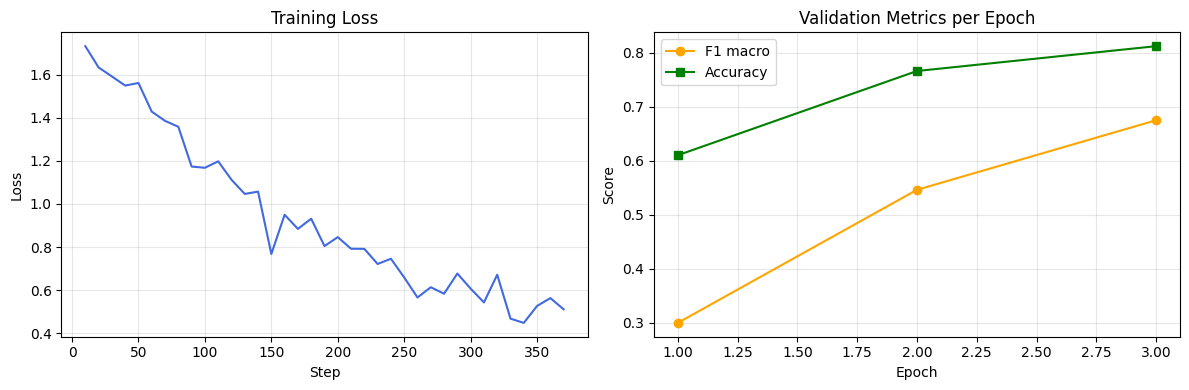

In [6]:
# --- Задание 2.3.5 (продолжение): История обучения ---

# Show training history table from trainer.state.log_history
log_history = trainer.state.log_history

# Separate training logs and eval logs
train_logs = [entry for entry in log_history if "loss" in entry and "eval_loss" not in entry]
eval_logs  = [entry for entry in log_history if "eval_loss" in entry]

if train_logs:
    train_hist_df = pd.DataFrame(train_logs)
    cols_to_show = [c for c in ["epoch", "step", "loss", "learning_rate"] if c in train_hist_df.columns]
    print("=== Training Loss History (first 10 entries) ===")
    print(train_hist_df[cols_to_show].head(10).to_string(index=False))

if eval_logs:
    eval_hist_df = pd.DataFrame(eval_logs)
    eval_cols = [c for c in ["epoch", "eval_loss", "eval_accuracy", "eval_f1_macro"] if c in eval_hist_df.columns]
    print("\n=== Evaluation History (per epoch) ===")
    print(eval_hist_df[eval_cols].to_string(index=False))

    # Plot training and eval loss
    if "loss" in pd.DataFrame(train_logs).columns and len(eval_logs) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Training loss
        train_df_hist = pd.DataFrame(train_logs)
        if "step" in train_df_hist.columns and "loss" in train_df_hist.columns:
            axes[0].plot(train_df_hist["step"], train_df_hist["loss"], color="royalblue")
            axes[0].set_title("Training Loss")
            axes[0].set_xlabel("Step")
            axes[0].set_ylabel("Loss")
            axes[0].grid(True, alpha=0.3)

        # Eval metrics per epoch
        eval_df_hist = pd.DataFrame(eval_logs)
        if "epoch" in eval_df_hist.columns:
            epochs = eval_df_hist["epoch"].values
            if "eval_f1_macro" in eval_df_hist.columns:
                axes[1].plot(epochs, eval_df_hist["eval_f1_macro"], marker="o", color="orange", label="F1 macro")
            if "eval_accuracy" in eval_df_hist.columns:
                axes[1].plot(epochs, eval_df_hist["eval_accuracy"], marker="s", color="green", label="Accuracy")
            axes[1].set_title("Validation Metrics per Epoch")
            axes[1].set_xlabel("Epoch")
            axes[1].set_ylabel("Score")
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
else:
    print("No evaluation logs found. Check training arguments.")

## Задание 2.3.6 – Оценка модели и анализ ошибок

NotebookProgressCallback removed.

=== Evaluation on VALIDATION set ===


Validation Loss     : 0.5940
Validation Accuracy : 0.8120
Validation F1 macro : 0.6748

=== Evaluation on TEST set ===


Test Loss     : 0.5683
Test Accuracy : 0.8260
Test F1 macro : 0.6658

Running trainer.predict on test set...


Predictions shape: (500,)

=== Classification Report (Test set) ===
              precision    recall  f1-score   support

     sadness     0.8497    0.8784    0.8638       148
         joy     0.8400    0.9735    0.9018       151
        love     0.6667    0.3590    0.4667        39
       anger     0.8219    0.7595    0.7895        79
        fear     0.7922    0.8714    0.8299        70
    surprise     1.0000    0.0769    0.1429        13

    accuracy                         0.8260       500
   macro avg     0.8284    0.6531    0.6658       500
weighted avg     0.8240    0.8260    0.8091       500


=== Confusion Matrix ===


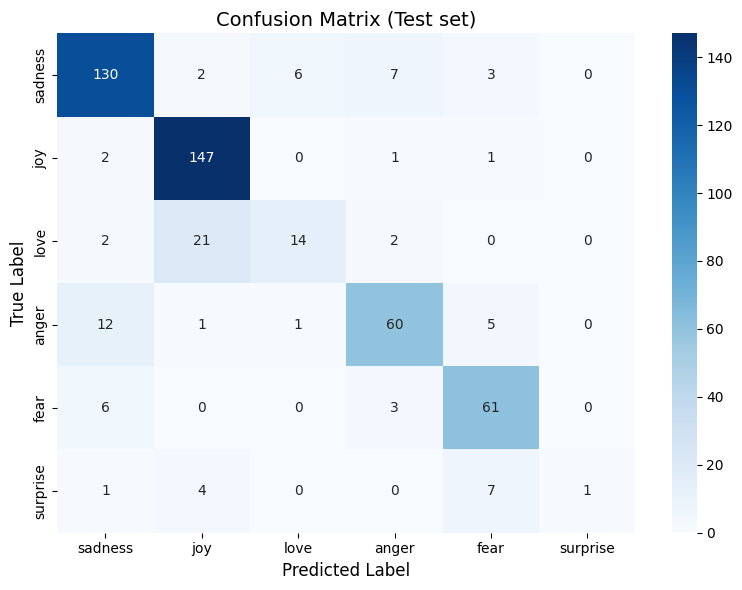

Confusion matrix saved to artifacts/confusion_matrix.png


In [7]:
# --- Задание 2.3.6: Оценка fine-tuned модели и анализ ошибок ---

# Remove NotebookProgressCallback before evaluate to avoid display issues
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
    print("NotebookProgressCallback removed.")
except Exception as e:
    print(f"Note: Could not remove NotebookProgressCallback: {e}")

# ---- Evaluate on validation set ----
print("\n=== Evaluation on VALIDATION set ===")
val_metrics = trainer.evaluate(eval_dataset=tokenized_ds["validation"])
print(f"Validation Loss     : {val_metrics.get('eval_loss', 'N/A'):.4f}")
print(f"Validation Accuracy : {val_metrics.get('eval_accuracy', 'N/A'):.4f}")
print(f"Validation F1 macro : {val_metrics.get('eval_f1_macro', 'N/A'):.4f}")

# ---- Evaluate on test set ----
print("\n=== Evaluation on TEST set ===")
test_metrics = trainer.evaluate(eval_dataset=tokenized_ds["test"])
test_acc = test_metrics.get('eval_accuracy', 0.0)
test_f1  = test_metrics.get('eval_f1_macro', 0.0)
print(f"Test Loss     : {test_metrics.get('eval_loss', 'N/A'):.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test F1 macro : {test_f1:.4f}")

# ---- Get predictions on test set ----
print("\nRunning trainer.predict on test set...")
test_pred_output = trainer.predict(tokenized_ds["test"])
test_logits      = test_pred_output.predictions
test_true_labels = test_pred_output.label_ids
test_pred_labels = np.argmax(test_logits, axis=-1)
test_confidences = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()

print(f"Predictions shape: {test_pred_labels.shape}")

# ---- Classification report ----
print("\n=== Classification Report (Test set) ===")
report = classification_report(
    test_true_labels,
    test_pred_labels,
    target_names=label_names,
    digits=4,
    zero_division=0,
)
print(report)

# ---- Confusion Matrix ----
print("\n=== Confusion Matrix ===")
os.makedirs("artifacts", exist_ok=True)

cm = confusion_matrix(test_true_labels, test_pred_labels)
fig, ax = plt.subplots(figsize=(8, 6))

if HAS_SEABORN:
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax,
    )
else:
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)
    tick_marks = np.arange(len(label_names))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(label_names, rotation=30, ha="right")
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(label_names)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

ax.set_title("Confusion Matrix (Test set)", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved to artifacts/confusion_matrix.png")

In [8]:
# --- Задание 2.3.6 (продолжение): Примеры предсказаний и анализ ошибок ---

# ---- Build predictions DataFrame ----
test_texts_all = [ex["text"] for ex in test_subset]
pred_confidences_top = [
    test_confidences[i][test_pred_labels[i]]
    for i in range(len(test_pred_labels))
]

predictions_df = pd.DataFrame({
    "text":        test_texts_all,
    "true_label":  [id2label[l] for l in test_true_labels],
    "pred_label":  [id2label[p] for p in test_pred_labels],
    "confidence":  pred_confidences_top,
    "correct":     [t == p for t, p in zip(test_true_labels, test_pred_labels)],
})

# ---- Show 10 sample predictions ----
print("=== 10 Sample Predictions from Test Set ===")
sample_show = predictions_df.head(10)[[
    "text", "true_label", "pred_label", "confidence"
]].copy()
sample_show["text"] = sample_show["text"].str[:60]
sample_show["confidence"] = sample_show["confidence"].round(4)
print(sample_show.to_string(index=False))

# ---- Error analysis: misclassified examples ----
errors_df = predictions_df[~predictions_df["correct"]].reset_index(drop=True)
print(f"\n=== Error Analysis ===")
print(f"Total test samples : {len(predictions_df)}")
print(f"Correct            : {predictions_df['correct'].sum()} ({predictions_df['correct'].mean()*100:.1f}%)")
print(f"Misclassified      : {len(errors_df)} ({len(errors_df)/len(predictions_df)*100:.1f}%)")

print("\n--- Misclassification breakdown by true class ---")
err_breakdown = errors_df.groupby(["true_label", "pred_label"]).size().reset_index(name="count")
err_breakdown = err_breakdown.sort_values("count", ascending=False)
print(err_breakdown.to_string(index=False))

print("\n--- 5+ Misclassified Examples with Commentary ---")
n_show = min(max(5, len(errors_df)), len(errors_df))
for i in range(min(n_show, 8)):
    row = errors_df.iloc[i]
    print(f"\n[Error {i+1}]")
    print(f"  Text        : {row['text'][:80]}")
    print(f"  True label  : {row['true_label']}")
    print(f"  Predicted   : {row['pred_label']} (conf={row['confidence']:.4f})")
    # Automated commentary based on confusion pattern
    if row["true_label"] == "sadness" and row["pred_label"] == "fear":
        print("  Comment     : Sadness and fear share negative valence; model may confuse them in short texts.")
    elif row["true_label"] == "joy" and row["pred_label"] == "love":
        print("  Comment     : Joy and love are both positive emotions; lexical overlap is high.")
    elif row["true_label"] == "love" and row["pred_label"] == "joy":
        print("  Comment     : Love and joy share positive affective language; model boundary is fuzzy.")
    elif row["true_label"] == "anger" and row["pred_label"] == "sadness":
        print("  Comment     : Anger expressed passively can resemble sadness in written text.")
    elif row["true_label"] == "fear" and row["pred_label"] == "sadness":
        print("  Comment     : Fear expressed without explicit fear words may be mis-tagged as sadness.")
    elif row["true_label"] == "surprise" and row["pred_label"] in ["joy", "fear"]:
        print("  Comment     : Surprise is the most ambiguous class; it can carry positive or negative tone.")
    else:
        print(f"  Comment     : Likely ambiguous text or lexical overlap between {row['true_label']} and {row['pred_label']}.")

=== 10 Sample Predictions from Test Set ===
                                                        text true_label pred_label  confidence
 im feeling rather rotten so im not very ambitious right now    sadness    sadness      0.5007
                   im updating my blog because i feel shitty    sadness    sadness      0.8728
i never make her separate from me because i don t ever want     sadness    sadness      0.8842
i left with my bouquet of red and yellow tulips under my arm        joy        joy      0.9067
             i was feeling a little vain when i did this one    sadness    sadness      0.7579
i cant walk into a shop anywhere where i do not feel uncomfo       fear       fear      0.6190
            i felt anger when at the end of a telephone call      anger      anger      0.7844
i explain why i clung to a relationship with a boy who was i        joy    sadness      0.7214
i like to have the same breathless feeling as a reader eager        joy        joy      0.5027
i jest

## Задание 2.3.7 – Сохранение артефактов

In [9]:
# --- Задание 2.3.7: Сохранение артефактов ---

# Ensure artifacts directory exists
os.makedirs("artifacts", exist_ok=True)

# ---- Save sample_predictions.csv ----
# Save at least 10-20 rows from test set predictions
n_save = min(20, len(predictions_df))
save_df = predictions_df[["text", "true_label", "pred_label", "confidence"]].head(n_save).copy()

csv_path = os.path.join("artifacts", "sample_predictions.csv")
save_df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"sample_predictions.csv saved to '{csv_path}' ({n_save} rows)")
print(save_df.head(5).to_string(index=False))

# ---- Confusion matrix was already saved above ----
cm_path = os.path.join("artifacts", "confusion_matrix.png")
if os.path.exists(cm_path):
    print(f"\nconfusion_matrix.png already saved to '{cm_path}'")
else:
    # Re-save if something went wrong earlier
    cm = confusion_matrix(test_true_labels, test_pred_labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    if HAS_SEABORN:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=label_names, yticklabels=label_names, ax=ax)
    else:
        ax.imshow(cm, cmap="Blues")
    ax.set_title("Confusion Matrix (Test set)")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.tight_layout()
    plt.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"confusion_matrix.png saved to '{cm_path}'")

# ---- Summary of saved artifacts ----
print("\n=== Summary of artifacts ===")
for fname in os.listdir("artifacts"):
    fpath = os.path.join("artifacts", fname)
    size  = os.path.getsize(fpath)
    print(f"  {fname}  ({size} bytes)")

print("\nArtifacts saved successfully")

sample_predictions.csv saved to 'artifacts\sample_predictions.csv' (20 rows)
                                                                                                             text true_label pred_label  confidence
                                                      im feeling rather rotten so im not very ambitious right now    sadness    sadness    0.500672
                                                                        im updating my blog because i feel shitty    sadness    sadness    0.872761
                i never make her separate from me because i don t ever want her to feel like i m ashamed with her    sadness    sadness    0.884233
i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived        joy        joy    0.906691
                                                                  i was feeling a little vain when i did this one    sadness    sadness    0.757906

confusion_matrix.png already saved

## Итоги

В данном ноутбуке были выполнены следующие задания:

- **Задание 2.3.1**: Настроены импорты, воспроизводимость (seed=42) и определено вычислительное устройство.
- **Задание 2.3.2**: Загружен датасет `emotion`, выделены подмножества (2000 / 500 / 500), проведён первичный анализ классов.
- **Задание 2.3.3**: Продемонстрирована токенизация (токены, input_ids, attention_mask), паддинг и усечение (truncation).
- **Задание 2.3.4**: Проведён инференс с предобученной моделью через `pipeline` и вручную через `AutoModelForSequenceClassification`.
- **Задание 2.3.5**: Выполнен fine-tuning `distilbert-base-uncased` на датасете emotion (3 эпохи, lr=2e-5).
- **Задание 2.3.6**: Оценена метрика на val/test, построены confusion matrix и classification report, проведён анализ ошибок.
- **Задание 2.3.7**: Сохранены артефакты: `artifacts/confusion_matrix.png` и `artifacts/sample_predictions.csv`.